In [16]:
from scipy.ndimage import gaussian_filter
import numpy as np

# Criar uma pasta e chamar de "harris"

def compute_harris_response(image, sigma=3):
    """
    Compute the Harris corner detector response function for each pixel in a graylevel image.
    """

    # Derivatives
    image_x = gaussian_filter(image, sigma, order=[0, 1])
    image_y = gaussian_filter(image, sigma, order=[1, 0])

    # Harris matrix components
    Wxx = gaussian_filter(image_x**2, sigma)
    Wxy = gaussian_filter(image_x*image_y, sigma)
    Wyy = gaussian_filter(image_y**2, sigma)

    # Determinant and trace
    w_det = Wxx * Wyy - Wxy**2
    w_trace = Wxx + Wyy

    # Harris response
    response = np.zeros_like(image)
    response[w_trace != 0] = w_det[w_trace != 0] / w_trace[w_trace != 0]

    return response

def filter_coordinates(coords, index, allowed_locations, min_dist):
    filtered_coords = []

    for i in index:
        x, y = coords[i]
        if allowed_locations[x, y] == 1:
            filtered_coords.append((x, y))

            # Calcula os limites da área a ser bloqueada
            x_min = max(x - min_dist, 0)
            x_max = min(x + min_dist + 1, allowed_locations.shape[0])
            y_min = max(y - min_dist, 0)
            y_max = min(y + min_dist + 1, allowed_locations.shape[1])

            # Bloqueia a área ao redor do ponto selecionado
            allowed_locations[x_min:x_max, y_min:y_max] = 0

    return filtered_coords

def get_harris_points(harrisim, min_dist=10, threshold=0.1):
    """ 
    Return corners from a Harris response image
    min_dist is the minimum number of pixels separating
    corners and image boundary. 
    """
    
    # find top corner candidates above a threshold
    corner_threshold = harrisim.max() * threshold
    harrisim_t = (harrisim > corner_threshold) * 1
    # get coordinates of candidates
    coords = np.array(harrisim_t.nonzero()).T
    # ...and their values
    candidate_values = [harrisim[c[0],c[1]] for c in coords]
    # sort candidates
    index = np.argsort(candidate_values)
    # store allowed point locations in array
    allowed_locations = np.zeros(harrisim.shape)
    allowed_locations[min_dist:-min_dist,min_dist:-min_dist] = 1

    # select the best points taking min_distance into account
    filtered_coords = filter_coordinates(coords, 
                        index, 
                        allowed_locations, 
                        min_dist)


    return filtered_coords

from pylab import figure, gray, imshow, plot, axis, show, array

def plot_harris_points(image,filtered_coords):
    """ 
    Plots corners found in image. 
    """
    
    figure()
    gray()
    imshow(image)
    plot([p[1] for p in filtered_coords],[p[0] for p in filtered_coords],"*")
    axis("off")
    show()

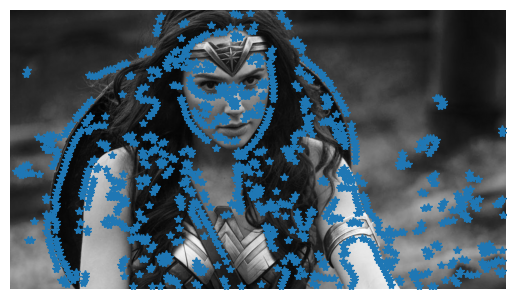

In [17]:
from PIL import Image

path_image = r"G:\py_projects\computer-vision\data\images\new_image.jpg"
image = array(Image.open(path_image).convert("L"))
harrisim = compute_harris_response(image)
filtered_coords = get_harris_points(harrisim,6)
plot_harris_points(image, filtered_coords)

###  Finding corresponding points between images

In [28]:
def get_descriptors(image,filtered_coords,wid=5):
    """ 
    For each point return pixel values around the point
    using a neighbourhood of width 2*wid+1. 
    (Assume points are extracted with min_distance > wid). 
    """
    desc = []
    for coords in filtered_coords:
        patch = image[coords[0]-wid:coords[0]+wid+1,
        coords[1]-wid:coords[1]+wid+1].flatten()

    desc.append(patch)
    return desc

def match(desc1,desc2,threshold=0.5):
    """ 
    For each corner point descriptor in the first image,
    select its match to second image using
    normalized cross correlation. 
    """
    n = len(desc1[0])
    # pair-wise distances
    d =-np.ones((len(desc1),len(desc2)))
    for i in range(len(desc1)):
        for j in range(len(desc2)):
            d1 = (desc1[i]- np.mean(desc1[i])) / np.std(desc1[i])
            d2 = (desc2[j]- np.mean(desc2[j])) / np.std(desc2[j])
            ncc_value = sum(d1 * d2) / (n-1)
            if ncc_value > threshold:
                d[i,j] = ncc_value

    ndx = np.argsort(-d)
    matchscores = ndx[:,0]
    return matchscores

def match_two_sided(desc1,desc2,threshold=0.5):
    """ Two-sided symmetric version of match(). """ 
    matches_12 = match(desc1,desc2,threshold)
    matches_21 = match(desc2,desc1,threshold)
    ndx_12 = np.where(matches_12 >= 0)[0]
    # remove matches that are not symmetric
    for n in ndx_12:
        if matches_21[matches_12[n]] != n:
            matches_12[n] =-1
    return matches_12


In [29]:
def appendimages(im1,im2):
    """ Return a new image that appends the two images side-by-side. """
    # select the image with the fewest rows and fill in enough empty rows
    rows1 = im1.shape[0]
    rows2 = im2.shape[0]
    if rows1 < rows2:
        im1 = np.concatenate((im1,np.zeros((rows2-rows1,im1.shape[1]))),axis=0)
    elif rows1 > rows2:
        im2 = np.concatenate((im2,np.zeros((rows1-rows2,im2.shape[1]))),axis=0)
    # if none of these cases they are equal, no filling needed.
    return np.concatenate((im1,im2), axis=1)


def plot_matches(im1,im2,locs1,locs2,matchscores,show_below=True):
    """ Show a figure with lines joining the accepted matches
    input: im1,im2 (images as arrays), locs1,locs2 (feature locations),
    matchscores (as output from "match()"),
    show_below (if images should be shown below matches). """
    im3 = appendimages(im1,im2)
    if show_below:
        im3 = np.vstack((im3,im3))
        imshow(im3)
        cols1 = im1.shape[1]
    for i,m in enumerate(matchscores):
        if m>0:
            plot([locs1[i][1],locs2[m][1]+cols1],[locs1[i][0],locs2[m][0]],"c")
    axis("off")

starting matching


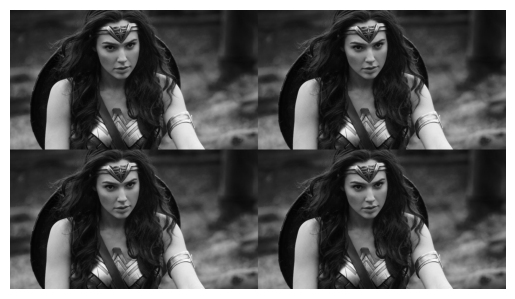

In [30]:
from PIL import Image

path_image = r"G:\py_projects\computer-vision\data\images\new_image.jpg"
im1 = array(Image.open(path_image).convert("L"))
im2 = array(Image.open(path_image).convert("L"))

wid = 5
harrisim = compute_harris_response(im1,5)
filtered_coords1 = get_harris_points(harrisim,wid+1)
d1 = get_descriptors(im1,filtered_coords1,wid)
harrisim = compute_harris_response(im2,5)
filtered_coords2 = get_harris_points(harrisim,wid+1)
d2 = get_descriptors(im2,filtered_coords2,wid)
print("starting matching")
matches = match_two_sided(d1,d2)
figure()
gray()
plot_matches(im1,im2,filtered_coords1,filtered_coords2,matches)
show()

In [27]:
len(d1[0])

TypeError: object of type 'builtin_function_or_method' has no len()